In [1]:
import tensorflow as tf
from timeit import default_timer as timer
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout, BatchNormalization, LSTM, ConvLSTM2D
from tensorflow.keras.losses import categorical_crossentropy


In [21]:
train_path = 'Combined Dataset/train'

In [22]:
test_path = 'Combined Dataset/test'


In [23]:
image_size = (150, 150)

batch_size = 32

In [24]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [25]:
train_generator = train_datagen.flow_from_directory(train_path,
                                                    target_size=image_size,
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    shuffle=True)

Found 10240 images belonging to 4 classes.


In [26]:
test_datagen = ImageDataGenerator(rescale=1./255)


validation_generator = test_datagen.flow_from_directory(
        test_path,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True)

Found 1279 images belonging to 4 classes.


In [27]:
labels = {value: key for key, value in train_generator.class_indices.items()}

print("Label in in train and validation datasets\n")

for key, value in labels.items():
    print(f'{key} : {value}')

Label in in train and validation datasets

0 : Mild Impairment
1 : Moderate Impairment
2 : No Impairment
3 : Very Mild Impairment


In [28]:
model = Sequential()

In [29]:
model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(4, activation='softmax'))

C:\Users\KIIT\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 37, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 41472)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       5,308,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,403,716 (20.61 MB)

 Trainable params: 5,403,012 (20.61 MB)

 Non-trainable params: 704 (2.75 KB)

In [31]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience = 5, min_lr =1e-6, verbose=1)

In [33]:
with tf.device('/GPU:0'):
    start = timer()
    history = model.fit(train_generator, validation_data = validation_generator, batch_size = 64, epochs= 40, verbose = 1)
    end = timer()

Epoch 1/40


C:\Users\KIIT\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


320/320 ━━━━━━━━━━━━━━━━━━━━ 326s 990ms/step - accuracy: 0.5946 - loss: 0.9892 - val_accuracy: 0.5004 - val_loss: 77.9433
Epoch 2/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 228s 709ms/step - accuracy: 0.7375 - loss: 0.6019 - val_accuracy: 0.3831 - val_loss: 3.4328
Epoch 3/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 228s 710ms/step - accuracy: 0.7611 - loss: 0.5416 - val_accuracy: 0.3104 - val_loss: 1.6249
Epoch 4/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 237s 738ms/step - accuracy: 0.7716 - loss: 0.5040 - val_accuracy: 0.6302 - val_loss: 0.8414
Epoch 5/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 241s 751ms/step - accuracy: 0.7904 - loss: 0.4614 - val_accuracy: 0.4394 - val_loss: 1.3702
Epoch 6/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 234s 728ms/step - accuracy: 0.8117 - loss: 0.4303 - val_accuracy: 0.3980 - val_loss: 1.7515
Epoch 7/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 226s 703ms/step - accuracy: 0.8203 - loss: 0.4135 - val_accuracy: 0.6724 - val_loss: 0.7178
Epoch 8/40
320/320 ━━━━━━━━━━━━━━━━━━━━ 229s 710ms/step - accuracy: 0.8255 - loss: 0.4

In [34]:
model.evaluate(validation_generator)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.8851 - loss: 0.2814


[0.31139686703681946, 0.8795934319496155]

In [35]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss')

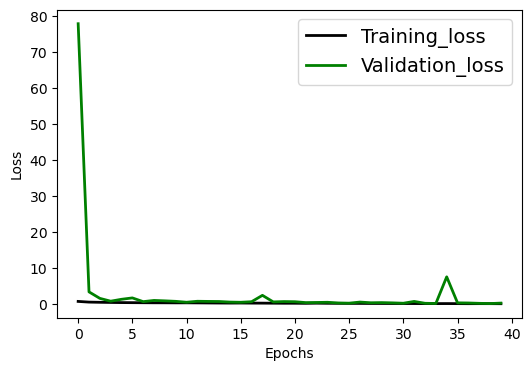

In [36]:
plt.figure(figsize=[6, 4])
plt.plot(history.history['loss'], 'black', linewidth=2.0)
plt.plot(history.history['val_loss'], 'green', linewidth=2.0)
plt.legend(['Training_loss', 'Validation_loss'],fontsize=14)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)

In [37]:
test_predictions = model.predict(validation_generator)
test_predictions_classes = np.where(test_predictions > 0.5, 1, 0)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step
